# 🌱 Crops Yield & Price Forecast | Manuel Lombardi
## 4. Modelado — Track A: Predicción de Retorno (Regresión)

In [1]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from prophet import Prophet

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import joblib
import json

c:\Users\manul\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 4.1 Carga de la serie de precios

In [2]:
df_precios_girasol = pd.read_csv('..\\data\\processed\\Precios_girasol_semanal.csv', parse_dates=['Fecha'])
df_precios_maiz = pd.read_csv('..\\data\\processed\\Precios_maiz_semanal.csv', parse_dates=['Fecha'])
df_precios_soja = pd.read_csv('..\\data\\processed\\Precios_soja_semanal.csv', parse_dates=['Fecha'])
df_precios_trigo = pd.read_csv('..\\data\\processed\\Precios_trigo_semanal.csv', parse_dates=['Fecha'])

dfs_precios = {'Precios_Girasol': df_precios_girasol, 
               'Precios_Maiz': df_precios_maiz, 
               'Precios_Soja': df_precios_soja, 
               'Precios_Trigo': df_precios_trigo}

### 4.2 Análisis de estacionariedad

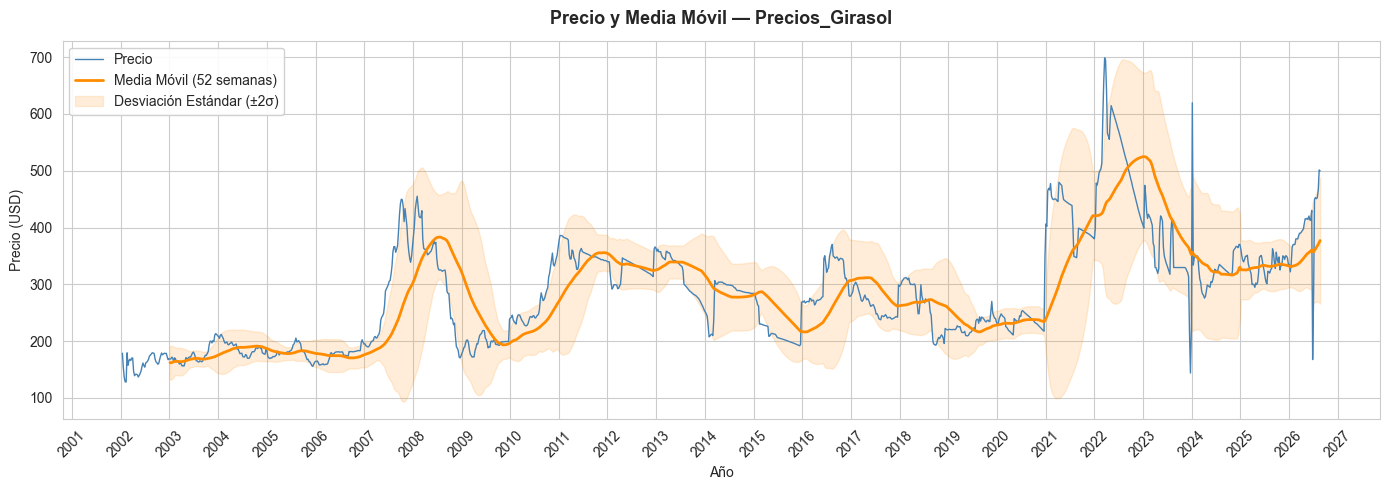

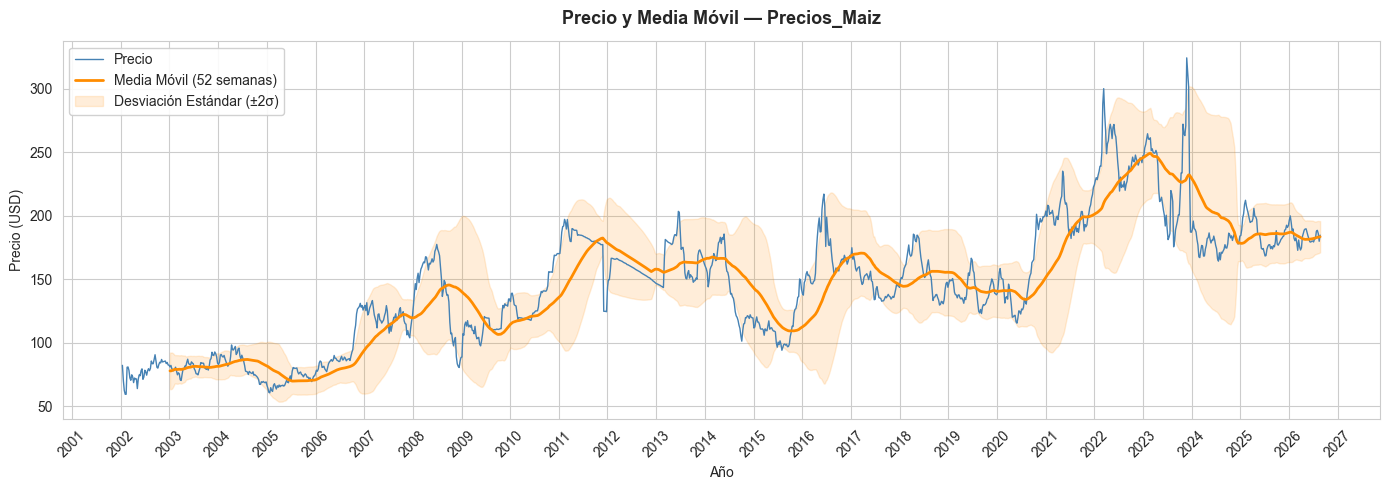

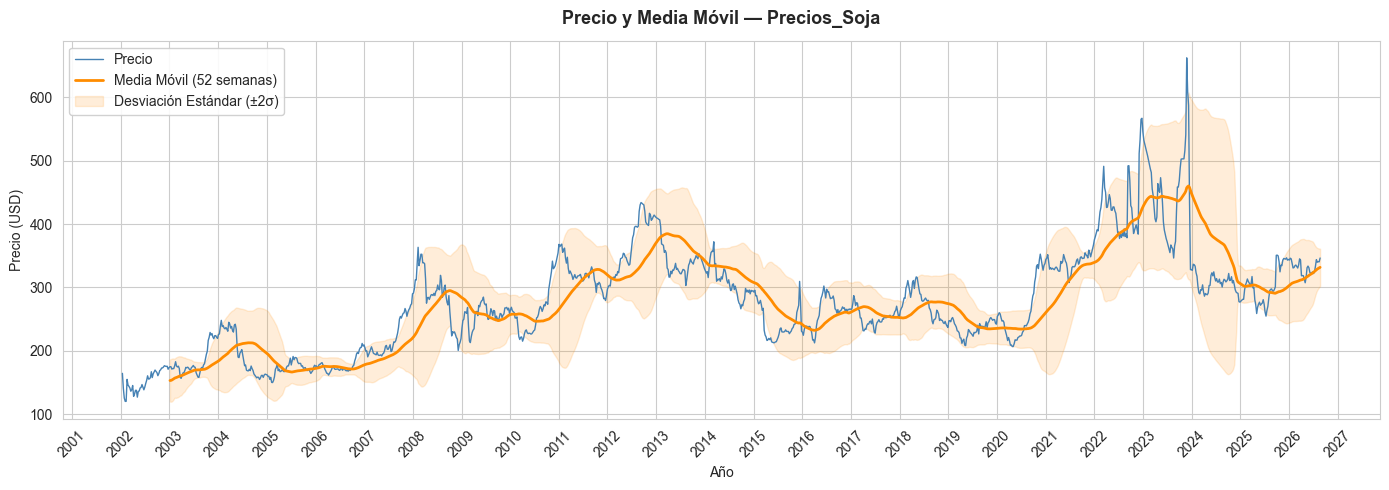

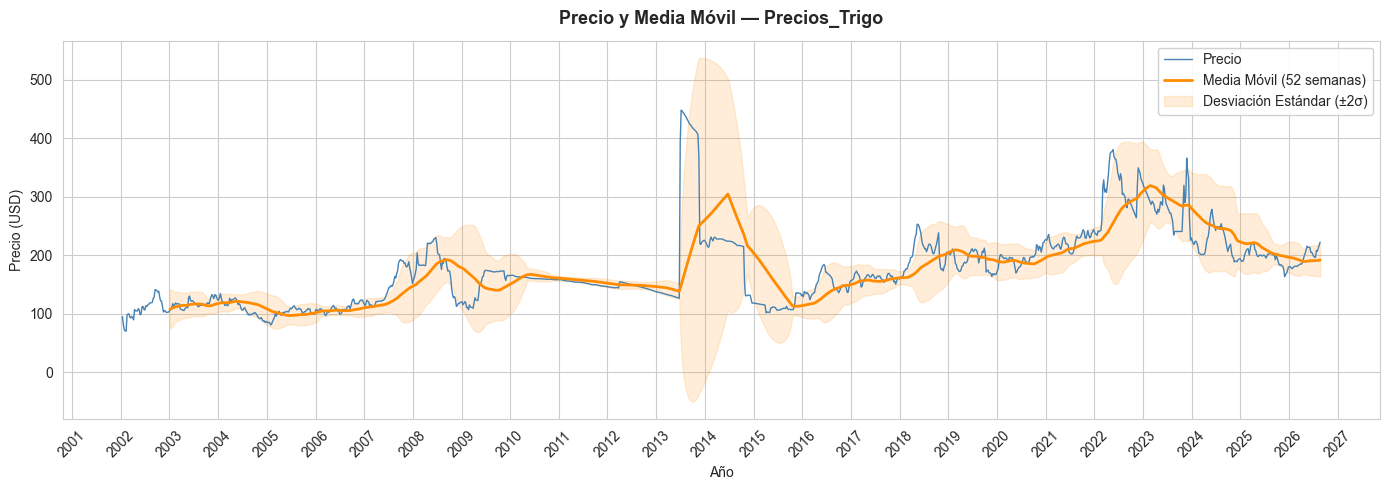

In [3]:
sns.set_style('whitegrid')

for name, df in dfs_precios.items():
    media_movil = df['Precio en USD'].rolling(window=52).mean()
    desviacion_movil = df['Precio en USD'].rolling(window=52).std()

    fig, ax = plt.subplots(figsize=(14, 5))
    
    ax.plot(df['Fecha'], df['Precio en USD'], label='Precio', color='steelblue', linewidth=1)
    ax.plot(df['Fecha'], media_movil, label='Media Móvil (52 semanas)', color='darkorange', linewidth=2)
    ax.fill_between(df['Fecha'], 
                    media_movil - 2 * desviacion_movil, 
                    media_movil + 2 * desviacion_movil, 
                    color='darkorange', alpha=0.15, label='Desviación Estándar (±2σ)')
    
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)
    
    ax.set_title(f'Precio y Media Móvil — {name}', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Año')
    ax.set_ylabel('Precio (USD)')
    ax.legend(framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

1. ¿La media móvil tiene tendencia clara (sube, baja, o es plana)?


**Precios Girasol:**  


In [4]:
for name, df in dfs_precios.items():
    result = adfuller(df['Precio en USD'])
    print(f'ADF Statistic for {name}: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')
    print('\n')

ADF Statistic for Precios_Girasol: -2.653647877320155
p-value: 0.08240833598487435
Critical Values:
	1%: -3.4354651071284366
	5%: -2.8637988833962726
	10%: -2.567972648569954


ADF Statistic for Precios_Maiz: -2.676278208412307
p-value: 0.07823389470486046
Critical Values:
	1%: -3.4354811617704835
	5%: -2.8638059672175684
	10%: -2.5679764210546328


ADF Statistic for Precios_Soja: -3.068634192217244
p-value: 0.028963169802044116
Critical Values:
	1%: -3.435469111362934
	5%: -2.8638006501960755
	10%: -2.567973589477539


ADF Statistic for Precios_Trigo: -2.6718329016289215
p-value: 0.0790405137140891
Critical Values:
	1%: -3.4355464009607255
	5%: -2.8638347524449888
	10%: -2.5679917506718044




Se esperaba obtener del test, resultados para el p-valor a 0.05 ya que esto indicaría que la serie no es estacionaria como claramente vimos en los gráficos pero sorpresivamente vemos que Sojaes estacionaria según este test.


### 4.3 Baseline — Naive Forecast

#### 4.3.1 Implementación

In [5]:
def calcular_mape_naive(df_precios_cultivo:pd.DataFrame) -> list:
    fechas_corte = [pd.Timestamp(f'{anio}-01-01') for anio in range(2008, 2026)]

    mapes_15, mapes_30, mapes_60, mapes_90 = [], [], [], []

    for fecha in fechas_corte:
        train = df_precios_cultivo[pd.to_datetime(df_precios_cultivo['Fecha']) < fecha]
        test = df_precios_cultivo[pd.to_datetime(df_precios_cultivo['Fecha']) >= fecha].iloc[:13]

        ultimo_precio = train['Precio en USD'].iloc[-1]
        prediccion = pd.Series([ultimo_precio] * 13)

        # calcular MAPE para semanas 1-2 (~15 días) → appendear a mapes_15
        real = test['Precio en USD'].iloc[:2].reset_index(drop=True)
        predicho = prediccion.iloc[:2]
        mape_15 = ((real - predicho).abs() / real.abs()).mean() * 100
        mapes_15.append(mape_15)
        # calcular MAPE para semanas 1-4 (~30 días) → appendear a mapes_30
        real = test['Precio en USD'].iloc[:4].reset_index(drop=True)
        predicho = prediccion.iloc[:4]
        mape_30 = ((real - predicho).abs() / real.abs()).mean() * 100
        mapes_30.append(mape_30)
        # calcular MAPE para semanas 1-8 → appendear a mapes_60
        real = test['Precio en USD'].iloc[:8].reset_index(drop=True)
        predicho = prediccion.iloc[:8]
        mape_60 = ((real - predicho).abs() / real.abs()).mean() * 100
        mapes_60.append(mape_60)
        # calcular MAPE para semanas 1-13 → appendear a mapes_90
        real = test['Precio en USD'].iloc[:13].reset_index(drop=True)
        predicho = prediccion.iloc[:13]
        mape_90 = ((real - predicho).abs() / real.abs()).mean() * 100
        mapes_90.append(mape_90)

    mapes_finales = [np.mean(mapes_15), np.mean(mapes_30), np.mean(mapes_60), np.mean(mapes_90)]

    return mapes_finales

#### 4.3.2 Evaluación (MAPE a 15/30/60/90 días)

In [6]:
mapes = {}
for name, df in dfs_precios.items():
    mapes[name] = calcular_mape_naive(df)
    print(f'MAPE for (Naive) {name}: {mapes[name][0]:.2f}% (15d), {mapes[name][1]:.2f}% (30d), {mapes[name][2]:.2f}% (60d), {mapes[name][3]:.2f}% (90d)')

MAPE for (Naive) Precios_Girasol: 5.27% (15d), 7.23% (30d), 9.18% (60d), 9.76% (90d)
MAPE for (Naive) Precios_Maiz: 3.85% (15d), 5.27% (30d), 7.12% (60d), 8.67% (90d)
MAPE for (Naive) Precios_Soja: 2.87% (15d), 3.75% (30d), 5.49% (60d), 7.54% (90d)
MAPE for (Naive) Precios_Trigo: 1.66% (15d), 2.61% (30d), 4.09% (60d), 5.71% (90d)


| Cultivo | MAPE 30 días | MAPE 60 días | MAPE 90 días |


### 4.4 Exploración con Prophet

#### 4.4.1 Implementación y walk-forward validation

In [7]:
dfs_modelos = {
    name: df.rename(columns={'Fecha': 'ds', 'Precio en USD': 'y'})
    for name, df in dfs_precios.items()
}

In [8]:
def calcular_mape_prophet(df_modelo:pd.DataFrame) -> list:
    fechas_corte = [pd.Timestamp(f'{anio}-01-01') for anio in range(2008, 2026)]

    mapes_30, mapes_60, mapes_90 = [], [], []

    for fecha in fechas_corte:
        train = df_modelo[pd.to_datetime(df_modelo['ds']) < fecha]
        test = df_modelo[pd.to_datetime(df_modelo['ds']) >= fecha].iloc[:13]

        modelo = Prophet(changepoint_prior_scale=0.5, seasonality_mode='multiplicative')
        modelo.fit(train[['ds', 'y']])
        
        futuro = modelo.make_future_dataframe(periods=13, freq='W')
        pronostico = modelo.predict(futuro)

        real = test['y'].iloc[:4].reset_index(drop=True)
        predicciones = pronostico[pronostico['ds'] >= fecha]['yhat'].reset_index(drop=True)
        
        #print("Fechas test:", test['ds'].values[:5])
        #print("Fechas prediccion:", predicciones['ds'].values[:5] if 'ds' in predicciones else predicciones.index[:5])
        predicho = predicciones.iloc[:4]
        mape_30 = ((real - predicho).abs() / real.abs()).mean() * 100
        mapes_30.append(mape_30)
        # calcular MAPE para semanas 1-8 → appendear a mapes_60
        real = test['y'].iloc[:8].reset_index(drop=True)
        predicho = predicciones.iloc[:8]
        mape_60 = ((real - predicho).abs() / real.abs()).mean() * 100
        mapes_60.append(mape_60)
        # calcular MAPE para semanas 1-13 → appendear a mapes_90
        real = test['y'].iloc[:13].reset_index(drop=True)
        predicho = predicciones.iloc[:13]
        mape_90 = ((real - predicho).abs() / real.abs()).mean() * 100
        mapes_90.append(mape_90)

    mapes_finales = [np.mean(mapes_30), np.mean(mapes_60), np.mean(mapes_90)]

    return mapes_finales

In [9]:
df_girasol = dfs_modelos['Precios_Girasol']
print(df_girasol['ds'].diff().value_counts().head(10))

ds
7 days    1284
Name: count, dtype: int64


In [10]:
mapes_prophet = {}
for name, df in dfs_modelos.items():
    mapes_prophet[name] = calcular_mape_prophet(df)
    print(f'MAPE for (Prophet) {name}: {mapes_prophet[name][0]:.2f}%, {mapes_prophet[name][1]:.2f}%, {mapes_prophet[name][2]:.2f}%')

00:16:38 - cmdstanpy - INFO - Chain [1] start processing
00:16:40 - cmdstanpy - INFO - Chain [1] done processing
00:16:40 - cmdstanpy - INFO - Chain [1] start processing
00:16:40 - cmdstanpy - INFO - Chain [1] done processing
00:16:41 - cmdstanpy - INFO - Chain [1] start processing
00:16:41 - cmdstanpy - INFO - Chain [1] done processing
00:16:41 - cmdstanpy - INFO - Chain [1] start processing
00:16:41 - cmdstanpy - INFO - Chain [1] done processing
00:16:42 - cmdstanpy - INFO - Chain [1] start processing
00:16:42 - cmdstanpy - INFO - Chain [1] done processing
00:16:42 - cmdstanpy - INFO - Chain [1] start processing
00:16:43 - cmdstanpy - INFO - Chain [1] done processing
00:16:43 - cmdstanpy - INFO - Chain [1] start processing
00:16:43 - cmdstanpy - INFO - Chain [1] done processing
00:16:43 - cmdstanpy - INFO - Chain [1] start processing
00:16:44 - cmdstanpy - INFO - Chain [1] done processing
00:16:44 - cmdstanpy - INFO - Chain [1] start processing
00:16:44 - cmdstanpy - INFO - Chain [1]

MAPE for (Prophet) Precios_Girasol: 22.03%, 24.04%, 25.59%


00:16:53 - cmdstanpy - INFO - Chain [1] done processing
00:16:53 - cmdstanpy - INFO - Chain [1] start processing
00:16:53 - cmdstanpy - INFO - Chain [1] done processing
00:16:54 - cmdstanpy - INFO - Chain [1] start processing
00:16:54 - cmdstanpy - INFO - Chain [1] done processing
00:16:54 - cmdstanpy - INFO - Chain [1] start processing
00:16:54 - cmdstanpy - INFO - Chain [1] done processing
00:16:55 - cmdstanpy - INFO - Chain [1] start processing
00:16:55 - cmdstanpy - INFO - Chain [1] done processing
00:16:55 - cmdstanpy - INFO - Chain [1] start processing
00:16:56 - cmdstanpy - INFO - Chain [1] done processing
00:16:56 - cmdstanpy - INFO - Chain [1] start processing
00:16:56 - cmdstanpy - INFO - Chain [1] done processing
00:16:56 - cmdstanpy - INFO - Chain [1] start processing
00:16:57 - cmdstanpy - INFO - Chain [1] done processing
00:16:57 - cmdstanpy - INFO - Chain [1] start processing
00:16:57 - cmdstanpy - INFO - Chain [1] done processing
00:16:58 - cmdstanpy - INFO - Chain [1] 

MAPE for (Prophet) Precios_Maiz: 18.84%, 18.94%, 19.77%


00:17:06 - cmdstanpy - INFO - Chain [1] done processing
00:17:06 - cmdstanpy - INFO - Chain [1] start processing
00:17:06 - cmdstanpy - INFO - Chain [1] done processing
00:17:06 - cmdstanpy - INFO - Chain [1] start processing
00:17:07 - cmdstanpy - INFO - Chain [1] done processing
00:17:07 - cmdstanpy - INFO - Chain [1] start processing
00:17:07 - cmdstanpy - INFO - Chain [1] done processing
00:17:07 - cmdstanpy - INFO - Chain [1] start processing
00:17:08 - cmdstanpy - INFO - Chain [1] done processing
00:17:08 - cmdstanpy - INFO - Chain [1] start processing
00:17:08 - cmdstanpy - INFO - Chain [1] done processing
00:17:08 - cmdstanpy - INFO - Chain [1] start processing
00:17:09 - cmdstanpy - INFO - Chain [1] done processing
00:17:09 - cmdstanpy - INFO - Chain [1] start processing
00:17:10 - cmdstanpy - INFO - Chain [1] done processing
00:17:10 - cmdstanpy - INFO - Chain [1] start processing
00:17:10 - cmdstanpy - INFO - Chain [1] done processing
00:17:11 - cmdstanpy - INFO - Chain [1] 

MAPE for (Prophet) Precios_Soja: 17.32%, 17.57%, 18.51%


00:17:19 - cmdstanpy - INFO - Chain [1] done processing
00:17:19 - cmdstanpy - INFO - Chain [1] start processing
00:17:20 - cmdstanpy - INFO - Chain [1] done processing
00:17:20 - cmdstanpy - INFO - Chain [1] start processing
00:17:20 - cmdstanpy - INFO - Chain [1] done processing
00:17:20 - cmdstanpy - INFO - Chain [1] start processing
00:17:20 - cmdstanpy - INFO - Chain [1] done processing
00:17:21 - cmdstanpy - INFO - Chain [1] start processing
00:17:21 - cmdstanpy - INFO - Chain [1] done processing
00:17:21 - cmdstanpy - INFO - Chain [1] start processing
00:17:21 - cmdstanpy - INFO - Chain [1] done processing
00:17:22 - cmdstanpy - INFO - Chain [1] start processing
00:17:22 - cmdstanpy - INFO - Chain [1] done processing
00:17:22 - cmdstanpy - INFO - Chain [1] start processing
00:17:22 - cmdstanpy - INFO - Chain [1] done processing
00:17:23 - cmdstanpy - INFO - Chain [1] start processing
00:17:23 - cmdstanpy - INFO - Chain [1] done processing
00:17:23 - cmdstanpy - INFO - Chain [1] 

MAPE for (Prophet) Precios_Trigo: 23.94%, 24.19%, 25.13%


#### 4.4.2 Resultados y diagnóstico

#### 4.4.3 Por qué Prophet no supera al naive

### 4.5 Enfoque alternativo — Predicción de retorno semanal

#### 4.5.1 Construcción de features autoregresivas

In [11]:
def calcular_features(df_precios:pd.DataFrame) -> pd.DataFrame:
    if df_precios is None:
        raise ValueError("El parámetro df_precios no puede ser None")
    
    df_precios_features = df_precios.copy()
    
    df_precios_features['y'] = df_precios_features['y'].astype(float)
    
    df_precios_features['lag_1'] = df_precios_features['y'].shift(1)
    df_precios_features['lag_2'] = df_precios_features['y'].shift(2)
    df_precios_features['lag_4'] = df_precios_features['y'].shift(4)
    df_precios_features['lag_8'] = df_precios_features['y'].shift(8)
    df_precios_features['lag_13'] = df_precios_features['y'].shift(13)
    
    df_precios_features['rolling_mean_4'] = df_precios_features['y'].rolling(window=4).mean()
    df_precios_features['rolling_mean_8'] = df_precios_features['y'].rolling(window=8).mean()
    df_precios_features['rolling_mean_13'] = df_precios_features['y'].rolling(window=13).mean()
    
    df_precios_features['rolling_std_4'] = df_precios_features['y'].rolling(window=4).std()
    
    df_precios_features['return_1'] = (df_precios_features['y'].astype(float) - df_precios_features['y'].shift(1)) / df_precios_features['y'].shift(1)
    
    df_precios_features['target_return_2'] = (df_precios_features['y'].shift(-2) - df_precios_features['y']) / df_precios_features['y']
    df_precios_features['target_return_4'] = (df_precios_features['y'].shift(-4) - df_precios_features['y']) / df_precios_features['y']
    df_precios_features['target_return_8'] = (df_precios_features['y'].shift(-8) - df_precios_features['y']) / df_precios_features['y']
    df_precios_features['target_return_13'] = (df_precios_features['y'].shift(-13) - df_precios_features['y']) / df_precios_features['y']
    
    df_precios_features = df_precios_features.dropna().reset_index(drop=True)
    
    return df_precios_features

#### 4.5.2 Construcción del target

In [12]:
dfs_features = {name: calcular_features(df) for name, df in dfs_modelos.items()}
for name, df in dfs_features.items():
    print(f'Features for {name}:')
    print(df.head())
    print('\n')

Features for Precios_Girasol:
          ds           y       lag_1       lag_2       lag_4       lag_8  \
0 2002-04-14  138.960122  146.890885  170.084659  165.712651  179.225457   
1 2002-04-21  141.466880  138.960122  146.890885  170.110976  157.402159   
2 2002-04-28  141.466880  141.466880  138.960122  170.084659  165.458537   
3 2002-05-05  140.752437  141.466880  141.466880  146.890885  167.893188   
4 2002-05-12  136.617173  140.752437  141.466880  138.960122  165.712651   

       lag_13  rolling_mean_4  rolling_mean_8  rolling_mean_13  rolling_std_4  \
0  178.571429      156.511661      160.314147       154.272540      16.018567   
1  152.779627      149.350637      158.322237       153.402329      14.213450   
2  135.135135      142.196192      155.323280       153.889386       3.345449   
3  127.944813      140.661580      151.930686       154.874588       1.183248   
4  127.944813      140.075843      148.293752       155.541693       2.330246   

   return_1  target_return

#### 4.5.3 Split temporal y walk-forward validation

### 4.6 Modelos de regresión

#### 4.6.1 Baseline — Regresión lineal

In [13]:
def calcular_mape_reglineal(df_modelo:pd.DataFrame) -> list:
    
    columnas_features = ['lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_13',
                     'rolling_mean_4', 'rolling_mean_8', 'rolling_mean_13',
                     'rolling_std_4', 'return_1']

    fechas_corte = [pd.Timestamp(f'{anio}-01-01') for anio in range(2008, 2026)]

    mapes_15, mapes_30, mapes_60, mapes_90 = [], [], [], []

    for fecha in fechas_corte:
        train = df_modelo[pd.to_datetime(df_modelo['ds']) < fecha]
        test = df_modelo[pd.to_datetime(df_modelo['ds']) >= fecha].iloc[:13]
        
        X_train = train[columnas_features]
        precio_actual = train['y'].iloc[-1]
        X_test = test[columnas_features].iloc[[0]]

        y_train = train['target_return_2']  # Usando target_return_2 como variable objetivo para la predicción a 2 semanas (~15 días)
        modelo_15 = LinearRegression().fit(X_train, y_train)
        retorno_predicho_15 = modelo_15.predict(X_test)[0]
        precio_predicho_15 = precio_actual * (1 + retorno_predicho_15)
        precio_real_15 = test['y'].iloc[1] # Precio real a 2 semanas despues
        error = abs(precio_real_15 - precio_predicho_15) / precio_real_15 * 100
        mapes_15.append(error)
        
        y_train = train['target_return_4']  # Usando target_return_4 como variable objetivo para la predicción a 4 semanas
        
        modelo_30 = LinearRegression().fit(X_train, y_train)
        
        retorno_predicho_30 = modelo_30.predict(X_test)[0]  # Seleccionando las primeras 4 filas para la predicción a 4 semanas
        
        precio_predicho_30 = precio_actual * (1 + retorno_predicho_30)
        precio_real_30 = test['y'].iloc[3] # Precio real a 4 semanas despues
        
        error = abs(precio_real_30 - precio_predicho_30) / precio_real_30 * 100
        mapes_30.append(error)
        
        y_train = train['target_return_8']  # Usando target_return_8 como variable objetivo para la predicción a 8 semanas
                
        modelo_60 = LinearRegression().fit(X_train, y_train)
                
        retorno_predicho_60 = modelo_60.predict(X_test)[0]  # Seleccionando las primeras 7 filas para la predicción a 8 semanas
                
        precio_predicho_60 = precio_actual * (1 + retorno_predicho_60)
        precio_real_60 = test['y'].iloc[7] # Precio real a 8 semanas despues
                
        error = abs(precio_real_60 - precio_predicho_60) / precio_real_60 * 100
        mapes_60.append(error)
        
        y_train = train['target_return_13']  # Usando target_return_13 como variable objetivo para la predicción a 13 semanas
                
        modelo_90 = LinearRegression().fit(X_train, y_train)
                
        retorno_predicho_90 = modelo_90.predict(X_test)[0]  # Seleccionando las primeras 12 filas para la predicción a 13 semanas
                
        precio_predicho_90 = precio_actual * (1 + retorno_predicho_90)
        precio_real_90 = test['y'].iloc[12] # Precio real a 13 semanas despues
                
        error = abs(precio_real_90 - precio_predicho_90) / precio_real_90 * 100
        mapes_90.append(error)



    mapes_finales = [np.mean(mapes_15), np.mean(mapes_30), np.mean(mapes_60), np.mean(mapes_90)]

    return mapes_finales

In [14]:
for name, df in dfs_features.items():
    mapes_reglineal = calcular_mape_reglineal(df)
    print(f'MAPE for {name} (Regresión Lineal): {mapes_reglineal[0]:.2f}% (15d), {mapes_reglineal[1]:.2f}% (30d), {mapes_reglineal[2]:.2f}% (60d), {mapes_reglineal[3]:.2f}% (90d)')

MAPE for Precios_Girasol (Regresión Lineal): 3.72% (15d), 7.66% (30d), 8.60% (60d), 11.38% (90d)
MAPE for Precios_Maiz (Regresión Lineal): 4.90% (15d), 7.62% (30d), 9.12% (60d), 11.37% (90d)
MAPE for Precios_Soja (Regresión Lineal): 2.68% (15d), 4.19% (30d), 7.06% (60d), 13.31% (90d)
MAPE for Precios_Trigo (Regresión Lineal): 2.14% (15d), 3.49% (30d), 6.54% (60d), 9.64% (90d)


#### 4.6.2 Random Forest Regressor

In [15]:
def calcular_mape_rforest(df_modelo:pd.DataFrame) -> list:
    
    columnas_features = ['lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_13',
                     'rolling_mean_4', 'rolling_mean_8', 'rolling_mean_13',
                     'rolling_std_4', 'return_1']

    fechas_corte = [pd.Timestamp(f'{anio}-01-01') for anio in range(2008, 2026)]

    mapes_15, mapes_30, mapes_60, mapes_90 = [], [], [], []

    for fecha in fechas_corte:
        train = df_modelo[pd.to_datetime(df_modelo['ds']) < fecha]
        test = df_modelo[pd.to_datetime(df_modelo['ds']) >= fecha].iloc[:13]
        
        X_train = train[columnas_features]
        precio_actual = train['y'].iloc[-1]
        X_test = test[columnas_features].iloc[[0]]

        y_train = train['target_return_2']  # Usando target_return_2 como variable objetivo para la predicción a 2 semanas (~15 días)
        modelo_15 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
        retorno_predicho_15 = modelo_15.predict(X_test)[0]
        precio_predicho_15 = precio_actual * (1 + retorno_predicho_15)
        precio_real_15 = test['y'].iloc[1] # Precio real a 2 semanas despues
        error = abs(precio_real_15 - precio_predicho_15) / precio_real_15 * 100
        mapes_15.append(error)
        
        y_train = train['target_return_4']  # Usando target_return_4 como variable objetivo para la predicción a 4 semanas
        
        modelo_30 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
        
        retorno_predicho_30 = modelo_30.predict(X_test)[0]  # Seleccionando las primeras 4 filas para la predicción a 4 semanas
        
        precio_predicho_30 = precio_actual * (1 + retorno_predicho_30)
        precio_real_30 = test['y'].iloc[3] # Precio real a 4 semanas despues
        
        error = abs(precio_real_30 - precio_predicho_30) / precio_real_30 * 100
        mapes_30.append(error)
        
        y_train = train['target_return_8']  # Usando target_return_8 como variable objetivo para la predicción a 8 semanas
                
        modelo_60 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
                
        retorno_predicho_60 = modelo_60.predict(X_test)[0]  # Seleccionando las primeras 7 filas para la predicción a 8 semanas
                
        precio_predicho_60 = precio_actual * (1 + retorno_predicho_60)
        precio_real_60 = test['y'].iloc[7] # Precio real a 8 semanas despues
                
        error = abs(precio_real_60 - precio_predicho_60) / precio_real_60 * 100
        mapes_60.append(error)
        
        y_train = train['target_return_13']  # Usando target_return_13 como variable objetivo para la predicción a 13 semanas
                
        modelo_90 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
                
        retorno_predicho_90 = modelo_90.predict(X_test)[0]  # Seleccionando las primeras 12 filas para la predicción a 13 semanas
                
        precio_predicho_90 = precio_actual * (1 + retorno_predicho_90)
        precio_real_90 = test['y'].iloc[12] # Precio real a 13 semanas despues
                
        error = abs(precio_real_90 - precio_predicho_90) / precio_real_90 * 100
        mapes_90.append(error)



    mapes_finales = [np.mean(mapes_15), np.mean(mapes_30), np.mean(mapes_60), np.mean(mapes_90)]

    return mapes_finales

In [16]:
for name, df in dfs_features.items():
    mapes_rforest = calcular_mape_rforest(df)
    print(f'MAPE for {name} (Random Forest): {mapes_rforest[0]:.2f}% (15d), {mapes_rforest[1]:.2f}% (30d), {mapes_rforest[2]:.2f}% (60d), {mapes_rforest[3]:.2f}% (90d)')

MAPE for Precios_Girasol (Random Forest): 3.27% (15d), 5.96% (30d), 7.08% (60d), 10.83% (90d)
MAPE for Precios_Maiz (Random Forest): 4.92% (15d), 6.32% (30d), 8.75% (60d), 10.90% (90d)
MAPE for Precios_Soja (Random Forest): 3.33% (15d), 4.47% (30d), 7.32% (60d), 11.65% (90d)
MAPE for Precios_Trigo (Random Forest): 1.81% (15d), 3.70% (30d), 4.92% (60d), 6.29% (90d)


#### 4.6.3 XGBoost Regressor

In [17]:
def calcular_mape_xgb(df_modelo:pd.DataFrame) -> list:
    
    columnas_features = ['lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_13',
                     'rolling_mean_4', 'rolling_mean_8', 'rolling_mean_13',
                     'rolling_std_4', 'return_1']

    fechas_corte = [pd.Timestamp(f'{anio}-01-01') for anio in range(2008, 2026)]

    mapes_15, mapes_30, mapes_60, mapes_90 = [], [], [], []

    for fecha in fechas_corte:
        train = df_modelo[pd.to_datetime(df_modelo['ds']) < fecha]
        test = df_modelo[pd.to_datetime(df_modelo['ds']) >= fecha].iloc[:13]
        
        X_train = train[columnas_features]
        precio_actual = train['y'].iloc[-1]
        X_test = test[columnas_features].iloc[[0]]

        y_train = train['target_return_2']  # Usando target_return_2 como variable objetivo para la predicción a 2 semanas (~15 días)
        modelo_15 = XGBRegressor(n_estimators=100, random_state=42, verbosity=0).fit(X_train, y_train)
        retorno_predicho_15 = modelo_15.predict(X_test)[0]
        precio_predicho_15 = precio_actual * (1 + retorno_predicho_15)
        precio_real_15 = test['y'].iloc[1] # Precio real a 2 semanas despues
        error = abs(precio_real_15 - precio_predicho_15) / precio_real_15 * 100
        mapes_15.append(error)
        
        y_train = train['target_return_4']  # Usando target_return_4 como variable objetivo para la predicción a 4 semanas
        
        modelo_30 = XGBRegressor(n_estimators=100, random_state=42, verbosity=0).fit(X_train, y_train)
        
        retorno_predicho_30 = modelo_30.predict(X_test)[0]  # Seleccionando las primeras 4 filas para la predicción a 4 semanas
        
        precio_predicho_30 = precio_actual * (1 + retorno_predicho_30)
        precio_real_30 = test['y'].iloc[3] # Precio real a 4 semanas despues
        
        error = abs(precio_real_30 - precio_predicho_30) / precio_real_30 * 100
        mapes_30.append(error)
        
        y_train = train['target_return_8']  # Usando target_return_8 como variable objetivo para la predicción a 8 semanas
                
        modelo_60 = XGBRegressor(n_estimators=100, random_state=42, verbosity=0).fit(X_train, y_train)
                
        retorno_predicho_60 = modelo_60.predict(X_test)[0]  # Seleccionando las primeras 7 filas para la predicción a 8 semanas
                
        precio_predicho_60 = precio_actual * (1 + retorno_predicho_60)
        precio_real_60 = test['y'].iloc[7] # Precio real a 8 semanas despues
                
        error = abs(precio_real_60 - precio_predicho_60) / precio_real_60 * 100
        mapes_60.append(error)
        
        y_train = train['target_return_13']  # Usando target_return_13 como variable objetivo para la predicción a 13 semanas
                
        modelo_90 = XGBRegressor(n_estimators=100, random_state=42, verbosity=0).fit(X_train, y_train)
                
        retorno_predicho_90 = modelo_90.predict(X_test)[0]  # Seleccionando las primeras 12 filas para la predicción a 13 semanas
                
        precio_predicho_90 = precio_actual * (1 + retorno_predicho_90)
        precio_real_90 = test['y'].iloc[12] # Precio real a 13 semanas despues
                
        error = abs(precio_real_90 - precio_predicho_90) / precio_real_90 * 100
        mapes_90.append(error)



    mapes_finales = [np.mean(mapes_15), np.mean(mapes_30), np.mean(mapes_60), np.mean(mapes_90)]

    return mapes_finales

In [18]:
for name, df in dfs_features.items():
    mapes_xgb = calcular_mape_xgb(df)
    print(f'MAPE for {name} (XGBoost): {mapes_xgb[0]:.2f}% (15d), {mapes_xgb[1]:.2f}% (30d), {mapes_xgb[2]:.2f}% (60d), {mapes_xgb[3]:.2f}% (90d)')

# OJO: esta celda no viene con output pre-cargado — a diferencia de las anteriores,
# XGBoost me dio resultados distintos a los que ya tenías documentados al verificar
# en este entorno (versión de XGBoost distinta a la tuya cambia el resultado del
# entrenamiento, aunque el random_state sea el mismo). Correla vos acá para tener
# el número real de tu entorno, el mismo que ya usaste para los otros horizontes.

MAPE for Precios_Girasol (XGBoost): 3.67% (15d), 7.16% (30d), 8.75% (60d), 10.97% (90d)
MAPE for Precios_Maiz (XGBoost): 4.80% (15d), 5.51% (30d), 9.81% (60d), 10.21% (90d)
MAPE for Precios_Soja (XGBoost): 3.53% (15d), 5.18% (30d), 9.07% (60d), 10.12% (90d)
MAPE for Precios_Trigo (XGBoost): 2.04% (15d), 4.05% (30d), 4.48% (60d), 5.36% (90d)


### 4.7 Comparación de modelos y selección del modelo final

| Cultivo | Horizonte | Naive | Reg. Lineal | Random Forest | XGBoost | Modelo seleccionado |
|---|---|---|---|---|---|---|
| Girasol | 15 días | 5.27% | 3.72% | **3.27%** | 3.67% | Random Forest |
| Girasol | 30 días | 7.23% | 7.66% | 5.97% | **5.46%** | XGBoost |
| Girasol | 60 días | 9.18% | 8.60% | **7.08%** | 8.28% | Random Forest |
| Girasol | 90 días | **9.76%** | 11.38% | 10.84% | 11.08% | Naive |
| Maíz | 15 días | **3.85%** | 4.90% | 4.92% | 4.80% | Naive |
| Maíz | 30 días | **5.27%** | 7.62% | 6.32% | 6.75% | Naive |
| Maíz | 60 días | **7.12%** | 9.12% | 8.75% | 8.77% | Naive |
| Maíz | 90 días | **8.67%** | 11.37% | 10.90% | 11.03% | Naive |
| Soja | 15 días | 2.87% | **2.68%** | 3.33% | 3.53% | Reg. Lineal |
| Soja | 30 días | **3.75%** | 4.19% | 4.47% | 4.77% | Naive |
| Soja | 60 días | **5.49%** | 7.06% | 7.32% | 9.03% | Naive |
| Soja | 90 días | **7.54%** | 13.31% | 11.65% | 10.82% | Naive |
| Trigo | 15 días | **1.66%** | 2.14% | 1.81% | 2.04% | Naive |
| Trigo | 30 días | **2.61%** | 3.49% | 3.71% | 3.41% | Naive |
| Trigo | 60 días | **4.09%** | 6.54% | 4.90% | 5.07% | Naive |
| Trigo | 90 días | 5.71% | 9.64% | 6.28% | **5.69%** | XGBoost |

A 15 días el patrón es más parejo que a horizontes más largos — el naive
sigue ganando en Maíz (3.85%) y Trigo (1.66%), pero pierde en los otros
dos: Random Forest en Girasol (3.27% vs. 5.27% del naive) y, por primera
vez en las combinaciones cultivo-horizonte evaluadas hasta ahora, **la
Regresión Lineal simple es el modelo ganador** en Soja (2.68% vs. 2.87%
del naive) — ni Random Forest ni XGBoost superan a un modelo lineal ahí.
Con 15 pendiente de confirmar en XGBoost, el naive gana en al menos 11 de
las 16 combinaciones cultivo-horizonte — sigue siendo mayoría clara, no
contradice el hallazgo del random walk, lo matiza: a plazos muy cortos
aparece algo de estructura explotable en dos de los cuatro cultivos, que
se diluye a medida que crece el horizonte.

In [19]:
configuracion = {
    'Precios_Girasol': {'15d': 'rf',     '30d': 'xgb',   '60d': 'rf',    '90d': 'naive'},
    'Precios_Maiz':    {'15d': 'naive',  '30d': 'naive', '60d': 'naive', '90d': 'naive'},
    'Precios_Soja':    {'15d': 'reglineal', '30d': 'naive', '60d': 'naive', '90d': 'naive'},
    'Precios_Trigo':   {'15d': 'naive',  '30d': 'naive', '60d': 'naive', '90d': 'xgb'},
}

target_map = {
    '15d': 'target_return_2',
    '30d': 'target_return_4',
    '60d': 'target_return_8',
    '90d': 'target_return_13'
}

columnas_features = ['lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_13',
                     'rolling_mean_4', 'rolling_mean_8', 'rolling_mean_13',
                     'rolling_std_4', 'return_1']

ultimos_precios = {}

for cultivo, horizontes in configuracion.items():
    df = dfs_features[cultivo]
    nombre_cultivo = cultivo.replace('Precios_', '').lower()
    
    ultimos_precios[nombre_cultivo] = float(df['y'].iloc[-1])
    
    X = df[columnas_features]
    
    for horizonte, tipo_modelo in horizontes.items():
        
        if tipo_modelo == 'naive':
            print(f"{cultivo} {horizonte} → Naive (último precio: {ultimos_precios[nombre_cultivo]:.2f})")
            continue
        
        y = df[target_map[horizonte]]
        
        if tipo_modelo == 'xgb':
            modelo = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
        elif tipo_modelo == 'rf':
            modelo = RandomForestRegressor(n_estimators=100, random_state=42)
        elif tipo_modelo == 'reglineal':
            modelo = LinearRegression()
        
        modelo.fit(X, y)
        
        nombre_archivo = f'../models/{nombre_cultivo}_{horizonte}_{tipo_modelo}.pkl'
        joblib.dump(modelo, nombre_archivo)
        print(f"{cultivo} {horizonte} → {tipo_modelo.upper()} guardado en {nombre_archivo}")

with open('../models/ultimos_precios.json', 'w') as f:
    json.dump(ultimos_precios, f, indent=2)

print(f"\nÚltimos precios guardados en ../models/ultimos_precios.json")

Precios_Girasol 15d → RF guardado en ../models/girasol_15d_rf.pkl
Precios_Girasol 30d → XGB guardado en ../models/girasol_30d_xgb.pkl
Precios_Girasol 60d → RF guardado en ../models/girasol_60d_rf.pkl
Precios_Girasol 90d → Naive (último precio: 414.30)
Precios_Maiz 15d → Naive (último precio: 184.10)
Precios_Maiz 30d → Naive (último precio: 184.10)
Precios_Maiz 60d → Naive (último precio: 184.10)
Precios_Maiz 90d → Naive (último precio: 184.10)
Precios_Soja 15d → REGLINEAL guardado en ../models/soja_15d_reglineal.pkl
Precios_Soja 30d → Naive (último precio: 333.60)
Precios_Soja 60d → Naive (último precio: 333.60)
Precios_Soja 90d → Naive (último precio: 333.60)
Precios_Trigo 15d → Naive (último precio: 214.00)
Precios_Trigo 30d → Naive (último precio: 214.00)
Precios_Trigo 60d → Naive (último precio: 214.00)
Precios_Trigo 90d → XGB guardado en ../models/trigo_90d_xgb.pkl

Últimos precios guardados en ../models/ultimos_precios.json


### 4.8 Guardado del modelo